# Stage 2: Data Acquisition, Exploration, and Preprocessing

This task involves a deep dive into the dataset to identify linguistic patterns, class imbalances, and noise. If the noise can be cleaned easily, we ensure higher quality inputs for the binary classifiers and a more reliable training process downstream.

## Exploratory Data Analysis (EDA) in NLP

Exploratory Data Analysis (EDA) in NLP focuses on uncovering linguistic patterns, structural properties, biases, and noise within text data before model training.

Skipping EDA means training blindly. Performing it leads to better modeling decisions.

---

### 1. Basic Statistical Profiling

Understand dataset structure before examining content.

- **Token Count**  
  Average, minimum, and maximum sentence length; helps determine `max_length` for transformer models.

- **Vocabulary Size**  
  Number of unique words; influences embedding size and model capacity.

- **Class Distribution**  
  Check for imbalance; prevents misleading metrics (for example, high accuracy from majority class guessing).

Outcome: decide on class weighting, resampling, or augmentation, and set appropriate sequence length.

---

### 2. Lexical Analysis (Word-Level Patterns)

Examine the actual words used in the dataset.

- **N-gram Analysis**  
  Identify frequent bigrams/trigrams; detect domain-specific phrases.

- **Stopword Density**  
  Estimate filler content; inform cleaning strategy.

- **Word Frequency / Word Clouds**  
  Quick visual check to ensure frequent words align with the task intent.

Outcome: detect shortcuts the model might exploit and identify task-relevant keywords.

---

### 3. Semantic & Syntactic Exploration

Go beyond surface statistics into linguistic structure.

- **POS Tagging**  
  Analyze distribution of nouns, verbs, adjectives, etc., to identify stylistic patterns.

- **Named Entity Recognition (NER)**  
  Detect frequent entities such as people, locations, or organizations.

- **Embedding Visualization (t-SNE / UMAP)**  
  Project embeddings into 2D space to observe natural clustering patterns.

Outcome: understand deeper structure before training and identify potential bias or semantic grouping.

---

### 4. Identifying Noise & Artifacts

Remove data issues before modeling.

- **Duplicates**  
  Prevent data leakage.

- **Special Characters / HTML Artifacts**  
  Clean tokens that could break the tokenizer.

- **Outliers**  
  Extremely short or long texts may indicate data collection errors.

Outcome: improve training stability and prevent misleading evaluation results.

---

## Why EDA Is Critical

EDA helps determine:

1. Whether class balancing or augmentation is needed.
2. Appropriate sequence length (`max_length`).
3. Whether the task is artificially easy due to keyword shortcuts.

Performing EDA ensures informed model design rather than blind training.

## Data Loading & Preparation

Three sources:
- `dontpatronizeme_pcl.tsv` — full labeled corpus (par_id, keyword, country, text, binary label, orig_label 0–4)
- `train/dev_semeval_parids-labels.csv` — official split IDs with task-2 multi-hot category labels
- `task4_test.tsv` — unlabeled test set (no labels; used only for final submission)

We use the local `dont_patronize_me.py` module to load the TSV, then merge in the split IDs.

In [2]:
import sys
import pandas as pd
from ast import literal_eval

sys.path.insert(0, ".")  # so dont_patronize_me.py is found from the notebooks/ dir
from dont_patronize_me import DontPatronizeMe

TASK2_CATS = [
    "unbalanced_power", "shallow_solution", "presupposition",
    "authority_voice", "metaphor", "compassion", "poorer_merrier"
]

# Load full labeled corpus (binary label + orig_label 0-4)
dpm = DontPatronizeMe("../data", "../data/task4_test.tsv")
dpm.load_task1()
dpm.load_test()

corpus  = dpm.train_task1_df.copy()
test_df = dpm.test_set_df.copy()

# Load official train/dev splits (par_id + task-2 multi-hot labels)
def load_ids(path):
    df = pd.read_csv(path, dtype={"par_id": str})
    cats = pd.DataFrame(df["label"].apply(literal_eval).tolist(), columns=TASK2_CATS)
    return pd.concat([df[["par_id"]], cats], axis=1)

train_ids = load_ids("../data/train_semeval_parids-labels.csv")
dev_ids   = load_ids("../data/dev_semeval_parids-labels.csv")

# Merge to get text + binary label + task-2 categories in one DataFrame
corpus["par_id"] = corpus["par_id"].astype(str)
train_df = train_ids.merge(corpus, on="par_id")
dev_df   = dev_ids.merge(corpus, on="par_id")

print(f"Corpus : {len(corpus):,} rows")
print(f"Train  : {len(train_df):,} rows  |  PCL: {train_df.label.sum()} ({train_df.label.mean():.1%})")
print(f"Dev    : {len(dev_df):,}  rows  |  PCL: {dev_df.label.sum()} ({dev_df.label.mean():.1%})")
print(f"Test   : {len(test_df):,}  rows  (unlabeled)")

Corpus : 10,469 rows
Train  : 8,375 rows  |  PCL: 794 (9.5%)
Dev    : 2,094  rows  |  PCL: 199 (9.5%)
Test   : 3,832  rows  (unlabeled)


## Stage 1: Basic Statistical Profiling

Before touching any words, we examine the raw structure of the **training set only** — the dev set is treated as held-out and not used to inform modelling decisions.

This tells us:
- **Class distribution** — how imbalanced is PCL vs No-PCL?
- **Token count** — average, min, max sequence lengths; sets our `max_length` and flags truncation risk
- **Vocabulary size** — how many unique words exist per class

In [4]:
import os
import re
import matplotlib.pyplot as plt
from collections import Counter

FIGURES_DIR = "../figures/stage1"
os.makedirs(FIGURES_DIR, exist_ok=True)

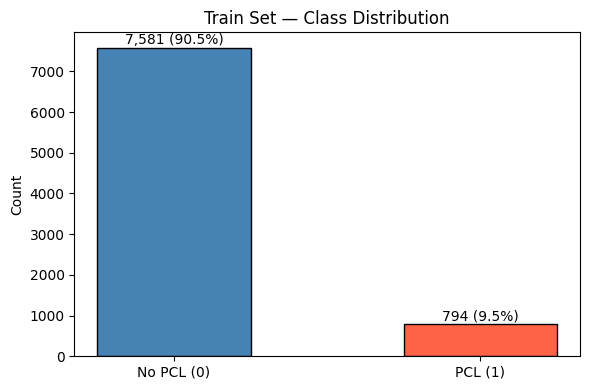

Negative : Positive ratio  = 9.5 : 1
Naive accuracy (predict all No-PCL) = 90.5%


In [5]:
counts = train_df["label"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["No PCL (0)", "PCL (1)"], counts.values,
              color=["steelblue", "tomato"], edgecolor="black", width=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            f"{val:,} ({val/len(train_df)*100:.1f}%)", ha="center", va="bottom")
ax.set_title("Train Set — Class Distribution")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

ratio = (train_df.label == 0).sum() / train_df.label.sum()
print(f"Negative : Positive ratio  = {ratio:.1f} : 1")
print(f"Naive accuracy (predict all No-PCL) = {(train_df.label == 0).mean():.1%}")

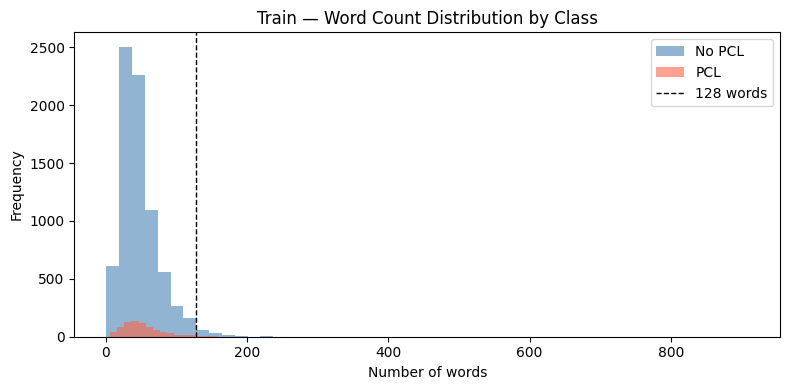

=== Word count statistics by class (Train) ===
         count       mean        std  min   50%   90%    95%     99%    max
label                                                                      
No PCL  7581.0  48.167656  29.183814  1.0  42.0  83.0  101.0  142.00  909.0
PCL      794.0  53.521411  33.673945  6.0  47.0  90.0  114.0  143.14  512.0


In [7]:
train_df["n_words"] = train_df["text"].str.split().str.len()

fig, ax = plt.subplots(figsize=(8, 4))
for label, colour, name in [(0, "steelblue", "No PCL"), (1, "tomato", "PCL")]:
    ax.hist(train_df.loc[train_df.label == label, "n_words"],
            bins=50, alpha=0.6, color=colour, label=name, edgecolor="none")
ax.axvline(128, color="black", linestyle="--", linewidth=1, label="128 words")
ax.set_title("Train — Word Count Distribution by Class")
ax.set_xlabel("Number of words")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/token_lengths.png", dpi=150, bbox_inches="tight")
plt.show()

print("=== Word count statistics by class (Train) ===")
print(train_df.groupby("label")["n_words"]
      .describe(percentiles=[0.5, 0.90, 0.95, 0.99])
      .rename(index={0: "No PCL", 1: "PCL"})
      .to_string())

In [8]:
def get_words(texts):
    return [w for t in texts for w in re.findall(r"\b[a-z']+\b", t.lower())]

pcl_words  = get_words(train_df.loc[train_df.label == 1, "text"])
npcl_words = get_words(train_df.loc[train_df.label == 0, "text"])

print("=== Vocabulary Statistics (Train) ===")
print(f"Total unique words  : {len(set(pcl_words) | set(npcl_words)):,}")
print(f"PCL vocab           : {len(set(pcl_words)):,}")
print(f"No-PCL vocab        : {len(set(npcl_words)):,}")
print(f"Shared              : {len(set(pcl_words) & set(npcl_words)):,}")
print(f"PCL-exclusive       : {len(set(pcl_words) - set(npcl_words)):,}")
print(f"No-PCL-exclusive    : {len(set(npcl_words) - set(pcl_words)):,}")

=== Vocabulary Statistics (Train) ===
Total unique words  : 26,043
PCL vocab           : 6,667
No-PCL vocab        : 24,732
Shared              : 5,356
PCL-exclusive       : 1,311
No-PCL-exclusive    : 19,376


### Stage 1 Findings

**Class Distribution**

The training set contains 8,375 examples, of which only 794 (9.5%) are PCL — a **9.5:1 negative-to-positive ratio**. This is a severe imbalance. A naive classifier that predicts "No PCL" for every example would achieve 90.5% accuracy, which makes raw accuracy a meaningless metric. The evaluation metric for this task is the **F1 score of the positive (PCL) class**, which directly penalises a model that ignores the minority class. This finding has an immediate impact on training strategy: the baseline downsamples negatives to a 2:1 ratio, but we should consider either **class-weighted loss** or **more principled resampling** to avoid the model collapsing to the majority class.

**Token / Sequence Length**

Both classes have similar median lengths (42 words for No-PCL, 47 for PCL), and the 99th percentile sits around 142–143 words. Only a small number of extreme outliers exceed 200 words. Crucially, the maximum No-PCL example is 909 words, while the maximum PCL example is 512 — meaning all PCL examples fit comfortably within RoBERTa's 512-token limit. Setting `max_length = 128` tokens would cover the 90th percentile of both classes, while `max_length = 256` covers virtually everything. Using the default 512 adds computational cost with no benefit for most examples. **We will use `max_length = 128` as the default, with 256 as a hyperparameter to test.**

**Vocabulary Size**

The PCL class has a vocabulary of 6,667 unique words, but only **1,311 of these (20%) are PCL-exclusive** — words that never appear in No-PCL examples. The remaining 80% of the PCL vocabulary is shared with the No-PCL class. This tells us PCL does not rely on a distinct set of "marker words" that a simple keyword filter could catch. The shared vocabulary means the model must learn **contextual and pragmatic signals** rather than surface-level word presence. This rules out simple bag-of-words approaches and reinforces the need for a contextualised model like RoBERTa.

## Stage 2: Lexical Analysis

We examine the actual words and phrases used in each class. All analysis is on the **training set only**.

- **N-gram analysis** — most distinctive bigrams/trigrams per class, revealing PCL-specific phrasing patterns
- **Stopword density** — proportion of filler words per class; informs whether aggressive cleaning is needed
- **Word frequency contrast** — words most over-represented in PCL vs No-PCL using log-odds ratio

In [10]:
import nltk
from nltk.util import ngrams
from nltk.corpus import stopwords

nltk.download("stopwords", quiet=True)
STOPWORDS = set(stopwords.words("english"))
FIGURES_DIR_2 = "../figures/stage2"
os.makedirs(FIGURES_DIR_2, exist_ok=True)

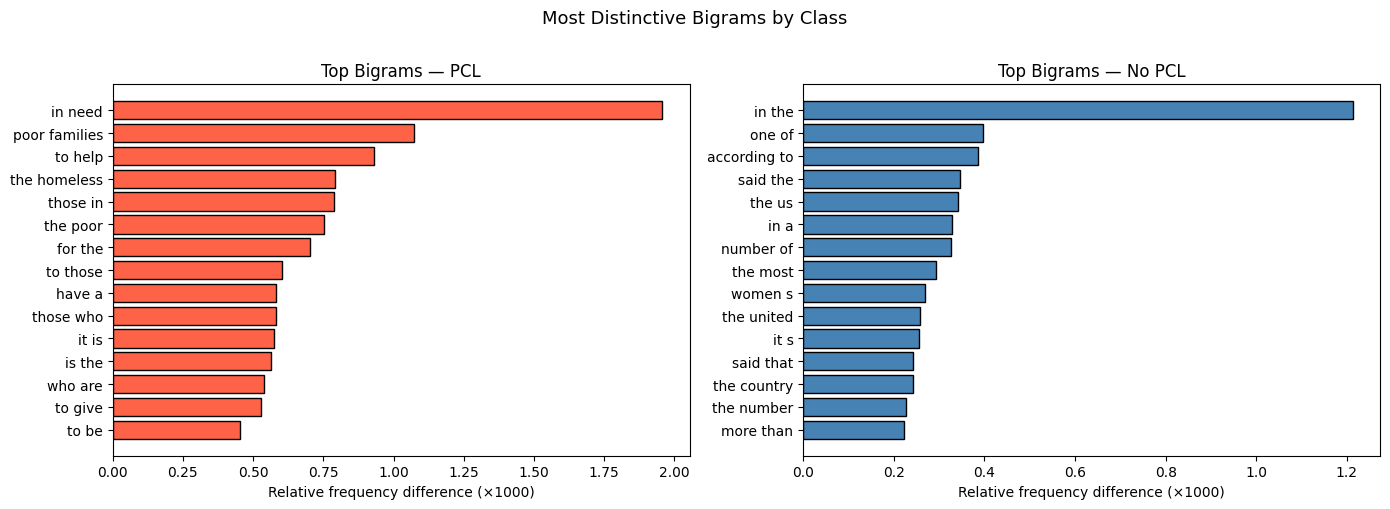

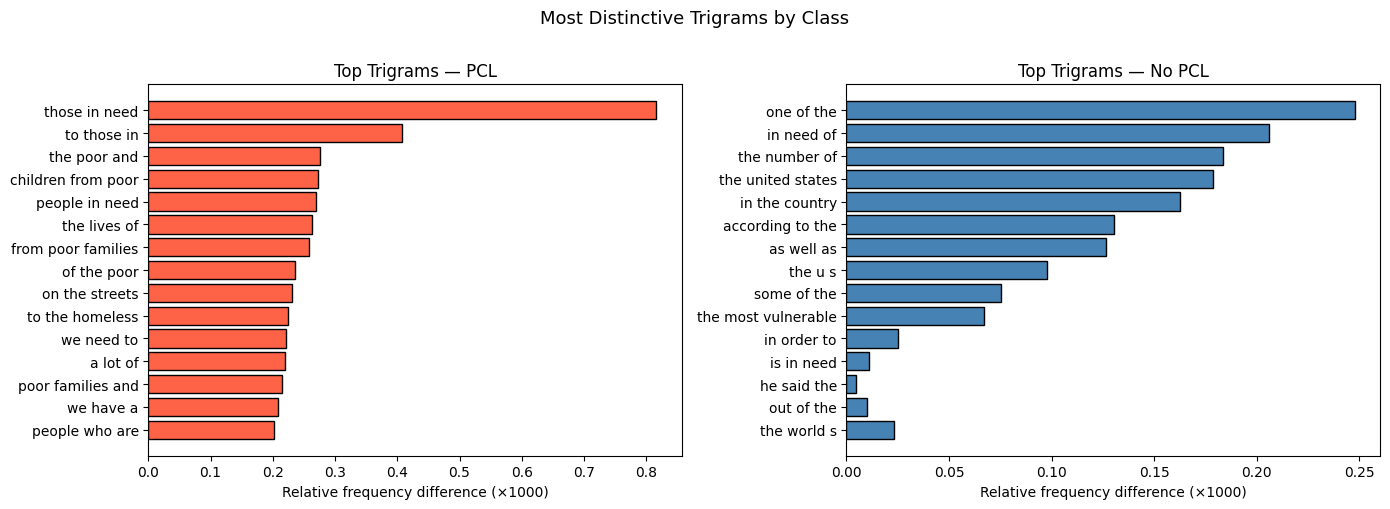

In [11]:
from nltk.util import ngrams as nltk_ngrams

def get_ngrams(texts, n):
    tokens_list = [re.findall(r"\b[a-z']+\b", t.lower()) for t in texts]
    all_ngrams = [ng for tokens in tokens_list for ng in nltk_ngrams(tokens, n)]
    return Counter(all_ngrams)

pcl_texts  = train_df.loc[train_df.label == 1, "text"].tolist()
npcl_texts = train_df.loc[train_df.label == 0, "text"].tolist()

for n, label in [(2, "Bigrams"), (3, "Trigrams")]:
    pcl_ng  = get_ngrams(pcl_texts, n)
    npcl_ng = get_ngrams(npcl_texts, n)

    # Score each n-gram by how much more common it is in PCL vs No-PCL (normalised)
    pcl_total  = sum(pcl_ng.values())
    npcl_total = sum(npcl_ng.values())
    all_ng = set(pcl_ng) | set(npcl_ng)
    scores = {
        ng: (pcl_ng[ng] / pcl_total) - (npcl_ng[ng] / npcl_total)
        for ng in all_ng if pcl_ng[ng] >= 5
    }

    top_pcl  = sorted(scores, key=scores.get, reverse=True)[:15]
    top_npcl = sorted(scores, key=scores.get)[:15]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, items, colour, title in [
        (axes[0], top_pcl,  "tomato",    f"Top {label} — PCL"),
        (axes[1], top_npcl, "steelblue", f"Top {label} — No PCL"),
    ]:
        phrases = [" ".join(ng) for ng in items]
        vals    = [abs(scores[ng]) * 1000 for ng in items]
        ax.barh(phrases[::-1], vals[::-1], color=colour, edgecolor="black")
        ax.set_title(title)
        ax.set_xlabel("Relative frequency difference (×1000)")

    plt.suptitle(f"Most Distinctive {label} by Class", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR_2}/distinctive_{label.lower()}.png", dpi=150, bbox_inches="tight")
    plt.show()

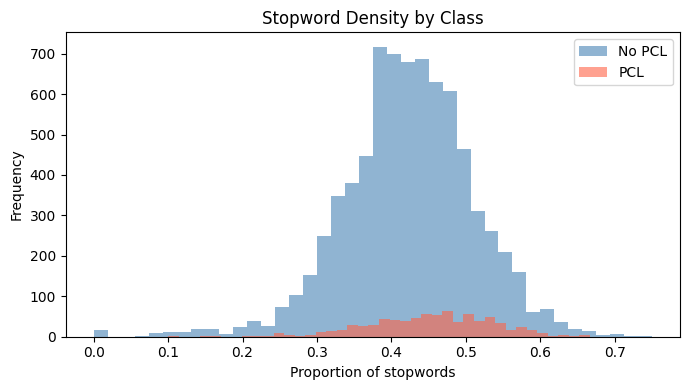

Mean stopword density — PCL   : 0.452
Mean stopword density — No PCL: 0.423


In [12]:
def stopword_density(texts):
    densities = []
    for t in texts:
        words = re.findall(r"\b[a-z']+\b", t.lower())
        if len(words) == 0:
            continue
        densities.append(sum(1 for w in words if w in STOPWORDS) / len(words))
    return densities

pcl_density  = stopword_density(pcl_texts)
npcl_density = stopword_density(npcl_texts)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(npcl_density, bins=40, alpha=0.6, color="steelblue", label="No PCL", edgecolor="none")
ax.hist(pcl_density,  bins=40, alpha=0.6, color="tomato",    label="PCL",    edgecolor="none")
ax.set_title("Stopword Density by Class")
ax.set_xlabel("Proportion of stopwords")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR_2}/stopword_density.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Mean stopword density — PCL   : {sum(pcl_density)/len(pcl_density):.3f}")
print(f"Mean stopword density — No PCL: {sum(npcl_density)/len(npcl_density):.3f}")

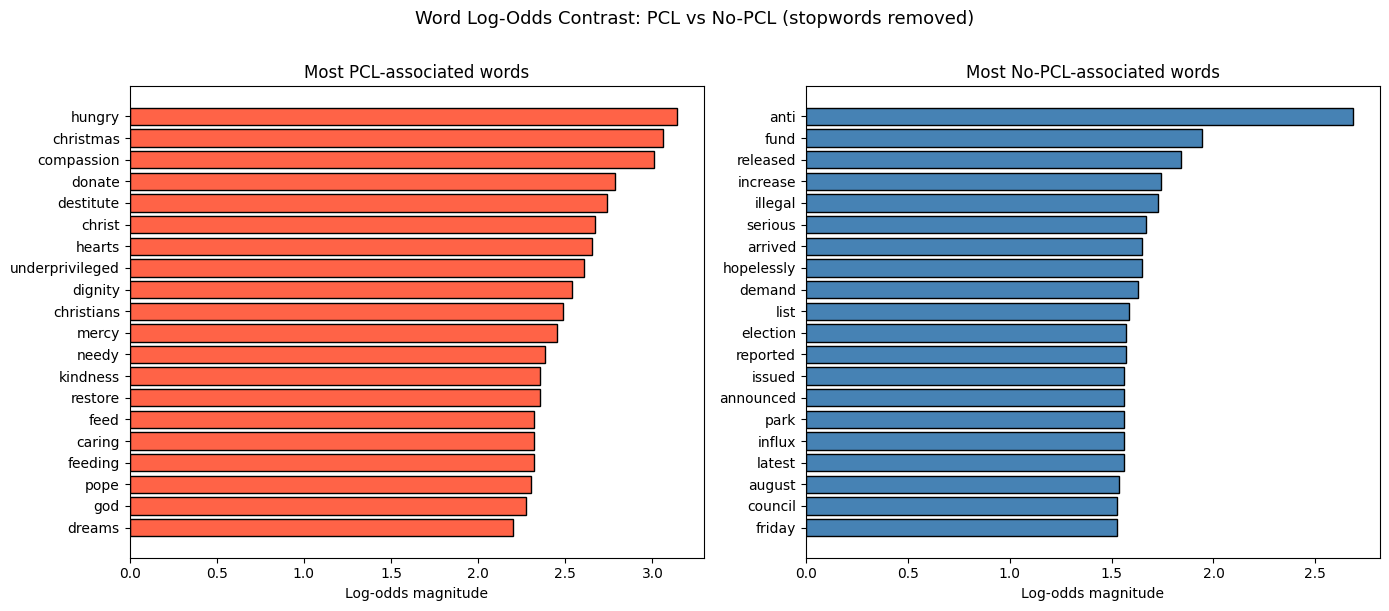

In [13]:
import numpy as np

def word_counts(texts):
    return Counter(w for t in texts for w in re.findall(r"\b[a-z']+\b", t.lower())
                   if w not in STOPWORDS and len(w) > 2)

pcl_counts  = word_counts(pcl_texts)
npcl_counts = word_counts(npcl_texts)

vocab = set(pcl_counts) | set(npcl_counts)
pcl_total  = sum(pcl_counts.values())
npcl_total = sum(npcl_counts.values())

# Log-odds with a simple Laplace smoothing
log_odds = {
    w: np.log((pcl_counts[w] + 1) / pcl_total) - np.log((npcl_counts[w] + 1) / npcl_total)
    for w in vocab if (pcl_counts[w] + npcl_counts[w]) >= 10
}

top_pcl  = sorted(log_odds, key=log_odds.get, reverse=True)[:20]
top_npcl = sorted(log_odds, key=log_odds.get)[:20]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, words, colour, title in [
    (axes[0], top_pcl,  "tomato",    "Most PCL-associated words"),
    (axes[1], top_npcl, "steelblue", "Most No-PCL-associated words"),
]:
    vals = [log_odds[w] for w in words]
    ax.barh(words[::-1], [abs(v) for v in vals[::-1]], color=colour, edgecolor="black")
    ax.set_title(title)
    ax.set_xlabel("Log-odds magnitude")

plt.suptitle("Word Log-Odds Contrast: PCL vs No-PCL (stopwords removed)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR_2}/log_odds_contrast.png", dpi=150, bbox_inches="tight")
plt.show()

### Stage 2 Findings

**N-gram Analysis**

The bigram and trigram charts reveal a clear and consistent pattern: PCL texts are dominated by phrases that frame vulnerable groups as objects of charity or pity — "in need", "poor families", "to help", "those in", "the homeless", "the poor", "to those", "those in need", "children from poor", "on the streets", "to the homeless". These are not neutral descriptions; they position the subjects as passive recipients. By contrast, the No-PCL bigrams are almost entirely structural ("in the", "one of", "according to", "said the") or factual/statistical ("the number", "the united states", "in the country"), reflecting straightforward news reporting with no patronising framing.

The trigram chart sharpens this further. "Those in need", "to those in", "the poor and", "people in need", "we need to", "we have a" are the most PCL-distinctive trigrams. The "we/those" contrast is particularly telling — PCL language often sets up a gap between the privileged "we" doing the helping and the vulnerable "those" being helped, which is exactly the "unbalanced power relations" category described in the research paper.

**Log-Odds Word Contrast**

The log-odds analysis (stopwords removed) makes the semantic character of PCL very explicit. The most PCL-associated single words are: **hungry, christmas, compassion, donate, destitute, christ, hearts, underprivileged, dignity, mercy, needy, kindness, feed, caring, pope, god**. These are words from the **"compassion" and "saviour" PCL categories** — emotional, charitable, often religious framing. No-PCL-associated words are mostly administrative or factual: **anti, fund, released, increase, illegal, serious, arrived, demand, election, council** — words from policy reporting and factual news.

This is a meaningful finding. It suggests that while PCL does have *some* lexically identifiable signal, the words themselves are not reliable classifiers — words like "hungry", "donate", or "dignity" can appear in perfectly neutral reporting. The **context in which they appear** is what distinguishes PCL, which reinforces that a contextualised model (RoBERTa) is the correct choice over any bag-of-words approach.

**Stopword Density**

Both classes have very similar stopword density distributions, both centred around 0.40–0.45. PCL texts have a marginally higher mean (0.452 vs 0.423), consistent with the flowery, adjective-heavy and structurally complex prose typical of "the poet" PCL category. The distributions overlap almost completely. This tells us that stopword removal would discard information the model needs — PCL is partly characterised by pronoun use ("we", "they", "those") and auxiliary structures ("to help", "we need to") which are stopwords. **We will not apply stopword removal as a preprocessing step.**